
### Architecture 
In this experiment, FiLM is applied at an early stage, immediately after the first MBConv stage (Stage 2 in the EfficientNet paper and the first accessbile on index 0 from timm). In the timm EfficientNet-B1 backbone, the stem convolution (Stage 1) is implemented as conv_stem + bn1 + act1, and the MBConv stages 2–8 are stored in blocks[0], block[1]..upto.blocks[6]. We therefore access the first block from timm by passing index 0(stage2) and insert FiLM after blocks[0], i.e., after Stage 2.



Stem (Stage 1): conv_stem → bn1 → act1

MBConv stages 2–8: stored in blocks[0]..blocks[6]

blocks[0] → Stage 2 ->FiLM(Early Modulation)

blocks[1] → Stage 3

blocks[2] → Stage 4

blocks[3] → Stage 5

blocks[4] → Stage 6

blocks[5] → Stage 7

blocks[6] → Stage 8

Head (Stage 9): conv_head → bn2 → global_pool → MLP

The tabular features are first encoded with a small MLP to produce a conditioning vector. This vector is fed into FiLM layers that generate per-channel scale and shift parameters, that can be applied to any block from stage 2 to stage 8, while stage 1 and stage 9 are stem and final head respectively, and we can modulate stage 2 to stage 8

<br>
<br>

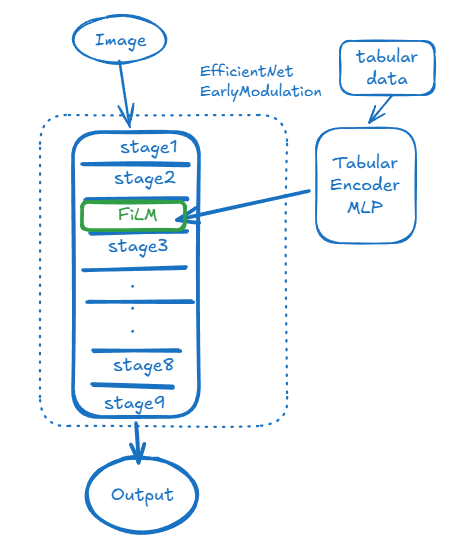



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_early_modulation_finetune_identity_init_bn_affine_true")   #

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_early_modulation_finetune_identity_init_bn_affine_true"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=0,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet )
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=True,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=False,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_early_modulation_finetune_identity_init_bn_affine_true: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=39.4564 | ValRMSE: 33.4697
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=27.9767 | ValRMSE: 23.9598
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=19.0830 | ValRMSE: 20.2299
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=13.9799 | ValRMSE: 20.0150
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=11.2461 | ValRMSE: 20.3199
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=9.6052 | ValRMSE: 20.2705
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=8.6478 | ValRMSE: 20.3644
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=8.0327 | ValRMSE: 20.3492
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=7.6243 | ValRMSE: 20.3949
Early stopping at epoch 9
Fold 1 best RMSE: 20.0150

=== exp12_film_fusion_effB1_internal_early_modulation_finetune_identity_init_bn_affine_true: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=39.3790 | ValRMSE: 31.6977
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=27.7649 | ValRMSE: 24.9592
Epoch 3/10 | Fol

In [5]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 20.0150 (n=1983)
Fold 2 OOF RMSE: 20.6283 (n=1983)
Fold 3 OOF RMSE: 19.4233 (n=1982)
Fold 4 OOF RMSE: 19.8630 (n=1982)
Fold 5 OOF RMSE: 20.4262 (n=1982)


### Train and Validation RMSE Curve

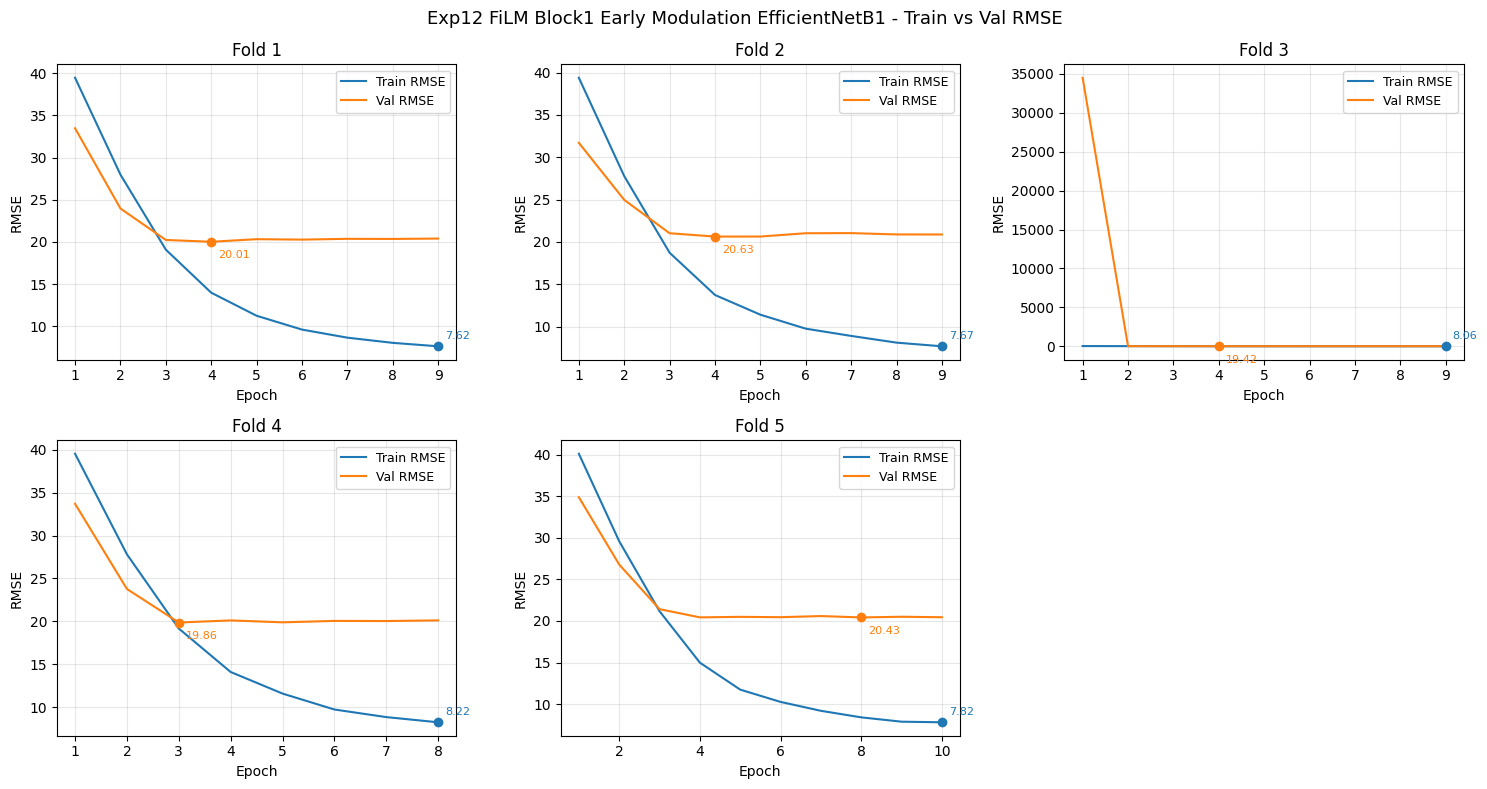

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block1 Early Modulation EfficientNetB1")

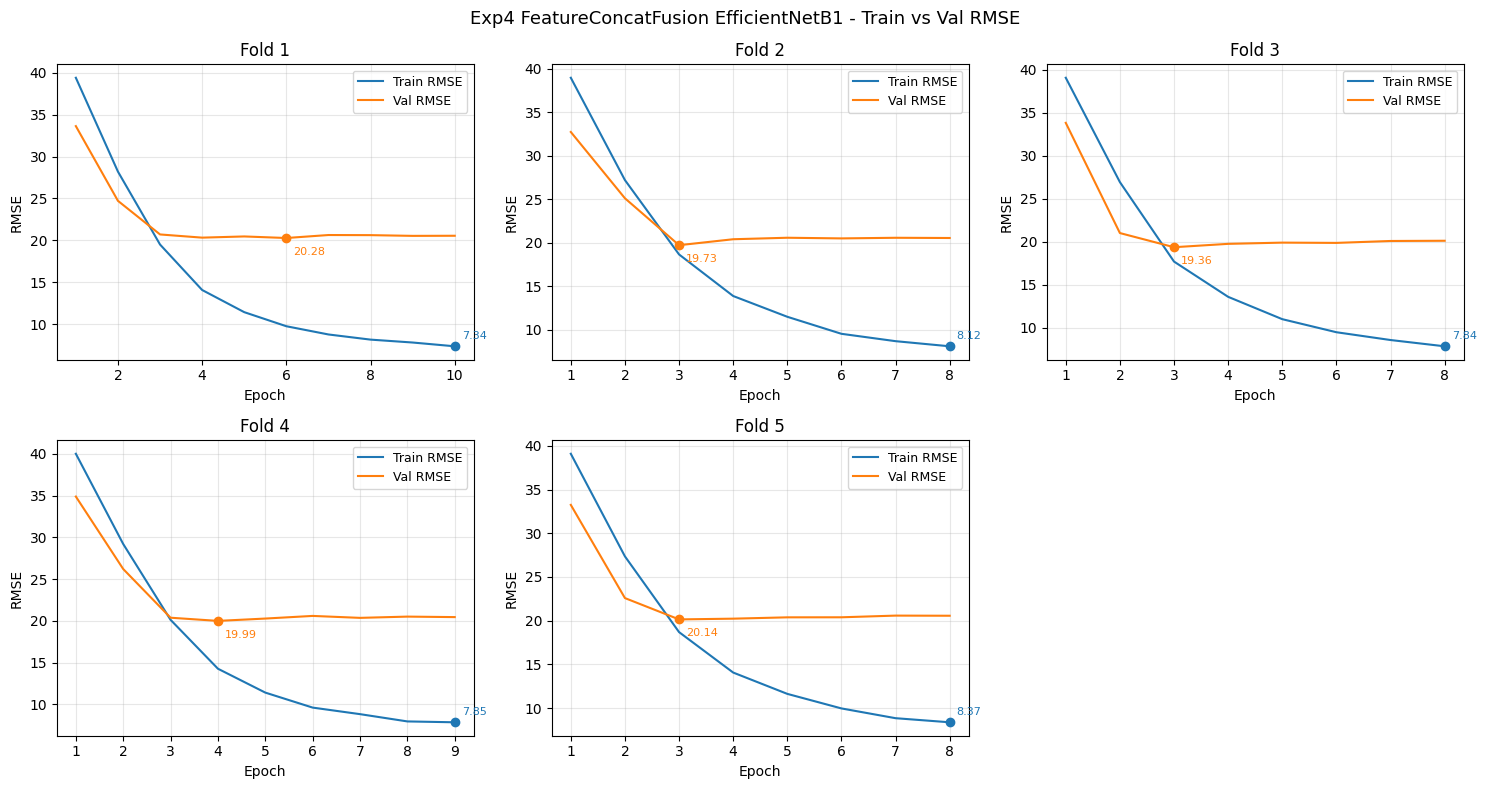

In [7]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

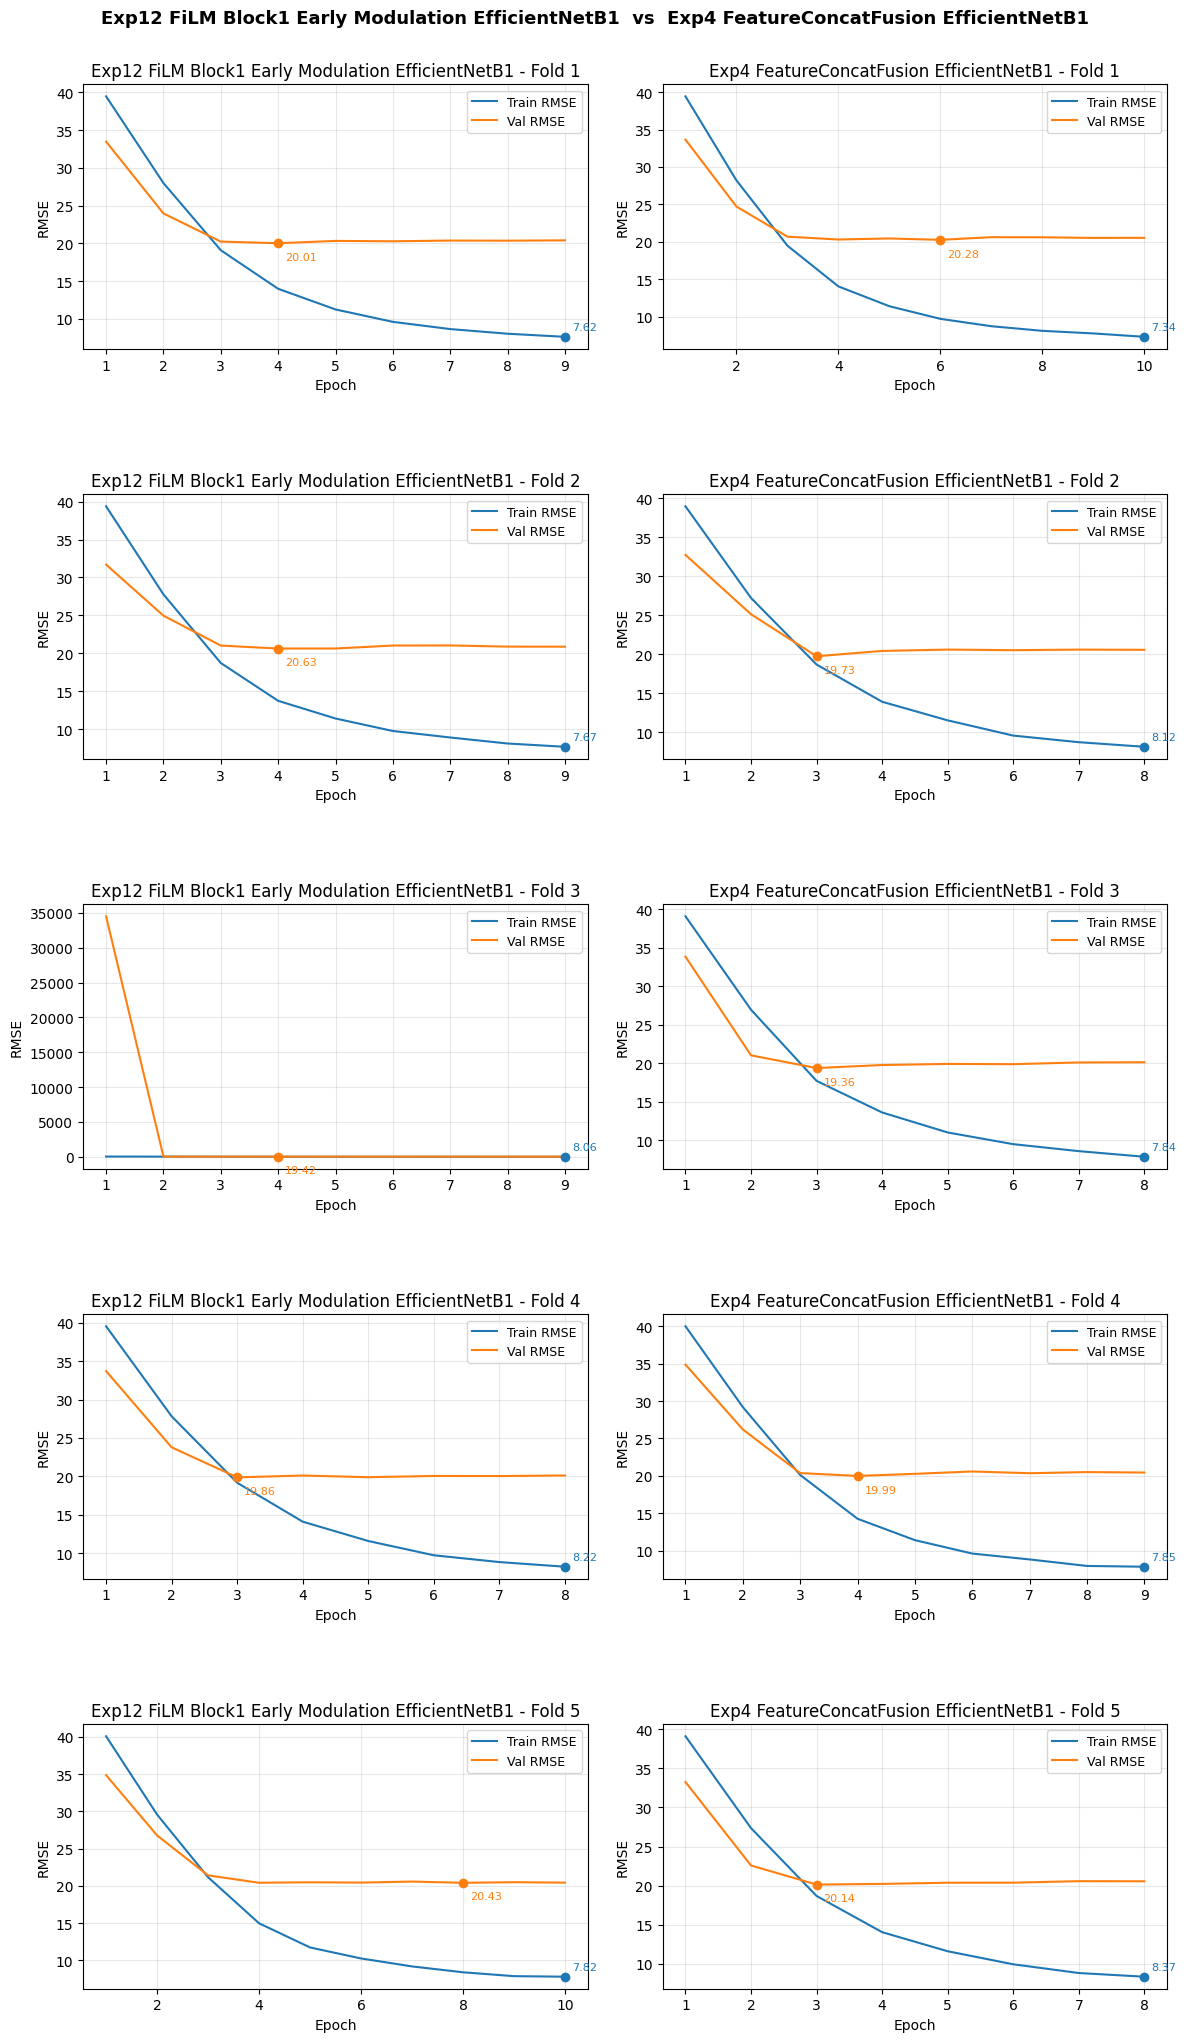

In [8]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM Block1 Early Modulation EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [9]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4c1e05895368c997fdd709bbd1ac3dae,2,2,91.353653,89.353653
1,bc872d6e6e1c93e1e2aa0b95594e3c7f,3,17,104.396019,87.396019
2,76769dbee1699e04ae1befa3128db7d6,2,100,15.383006,84.616994
3,4ab407534f6153ba427f901eb2b45c5b,3,100,15.607821,84.392179
4,e5a84da44afc0abddfbb36907a5ee845,5,100,17.836485,82.163515


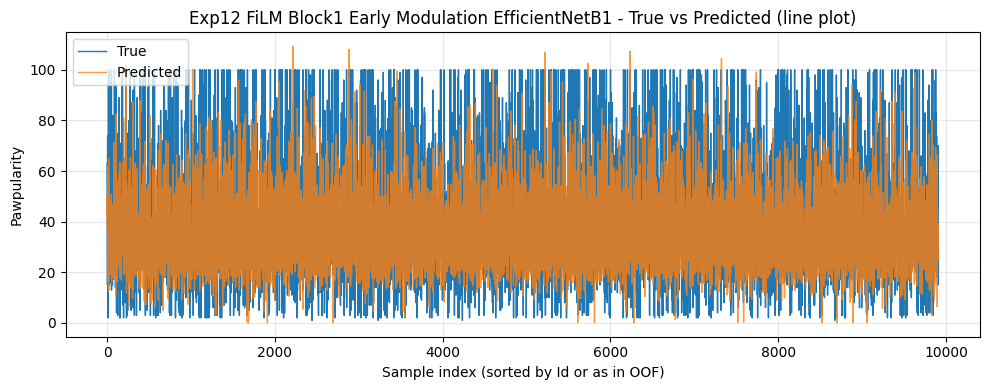

In [10]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12 FiLM Block1 Early Modulation EfficientNetB1")





Exp12 FiLM Block1 Early Modulation EfficientNetB1 OOF RMSE: 20.07571602090405
Exp4_FeatureConcat EffB1 Fusion OOF RMSE: 19.90331621767278
ΔRMSE (Exp4_FeatureConcat EffB1 Fusion - Exp12 FiLM Block1 Early Modulation EfficientNetB1): -0.17239980323126858


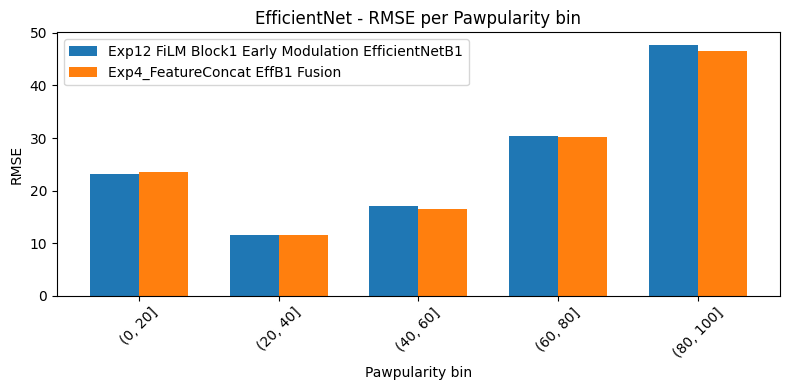

In [11]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12 FiLM Block1 Early Modulation EfficientNetB1",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

In [12]:
df_bins.head()

,bin,count,Exp12 FiLM Block1 Early Modulation EfficientNetB1_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,23.209199,23.561754,0.352555,Exp12 FiLM Block1 Early Modulation EfficientNe...
1,"(20, 40]",5119,11.534733,11.605182,0.070448,Exp12 FiLM Block1 Early Modulation EfficientNe...
2,"(40, 60]",2088,17.019223,16.538259,-0.480963,Exp4_FeatureConcat EffB1 Fusion_better
3,"(60, 80]",727,30.318455,30.127592,-0.190863,Exp4_FeatureConcat EffB1 Fusion_better
4,"(80, 100]",561,47.718728,46.623998,-1.094729,Exp4_FeatureConcat EffB1 Fusion_better


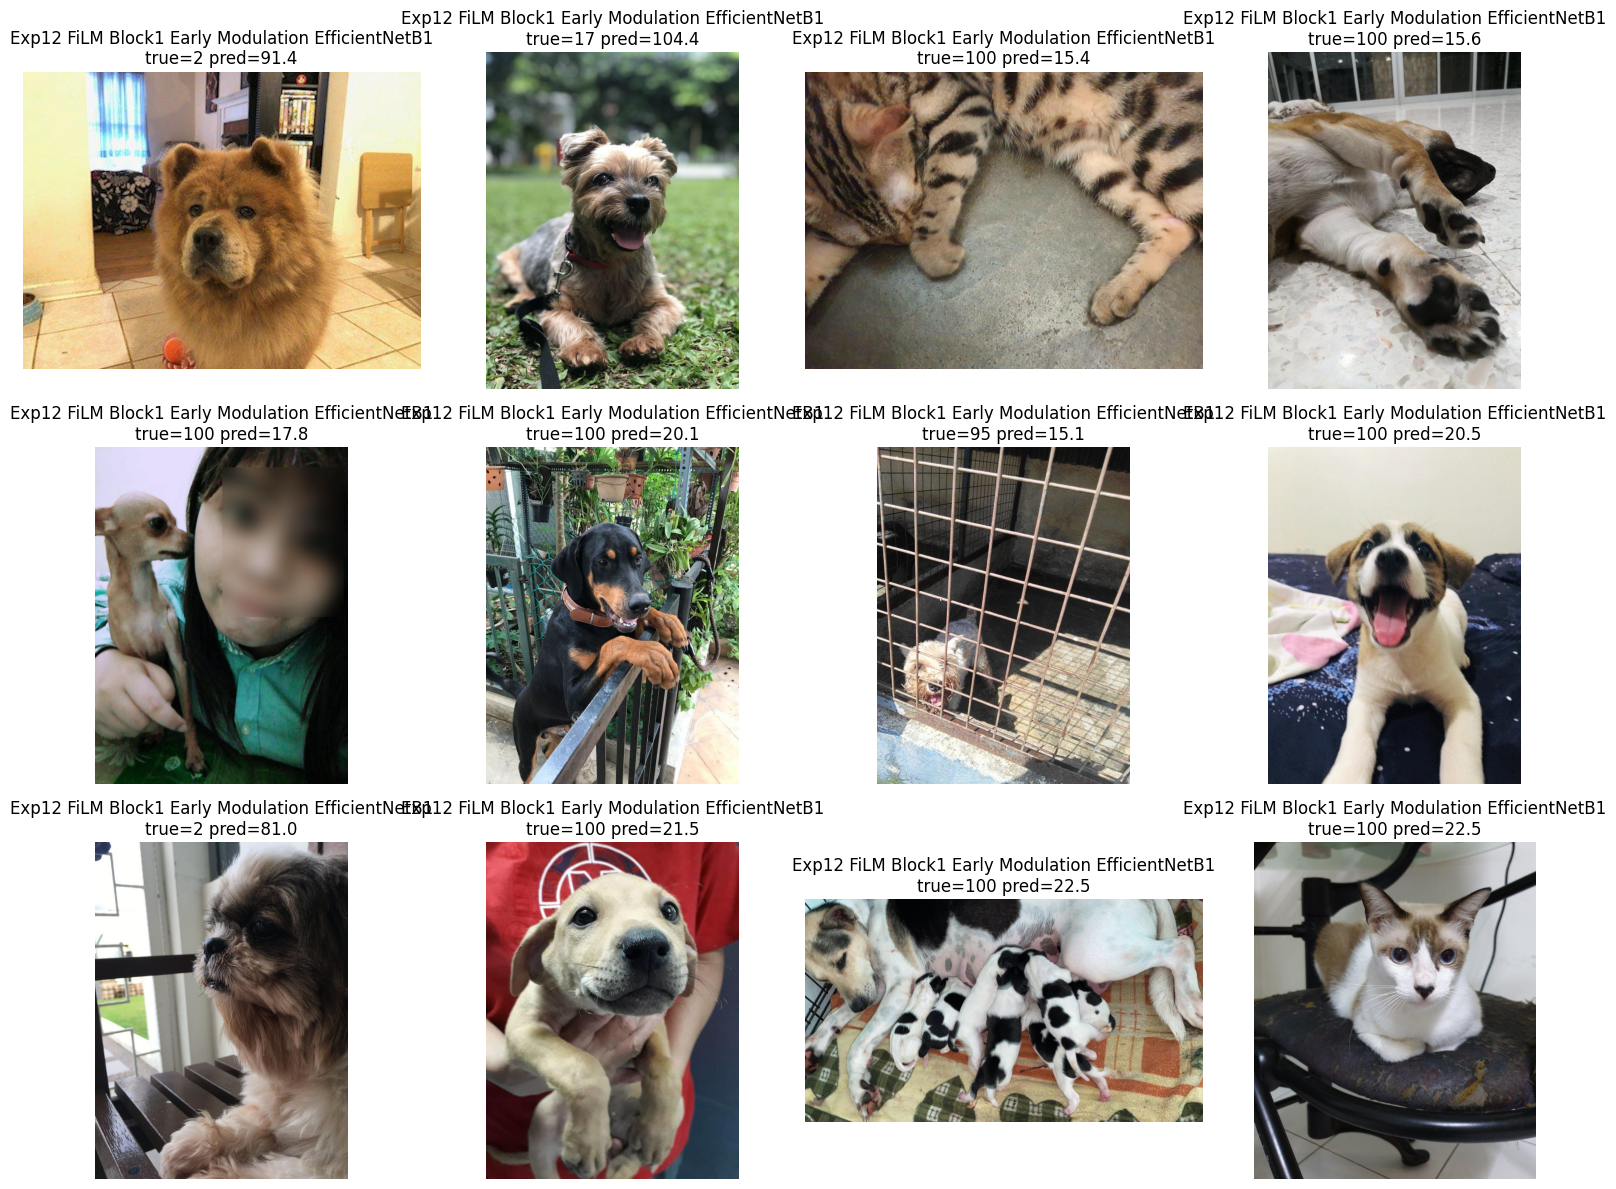

In [13]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp12 FiLM Block1 Early Modulation EfficientNetB1")

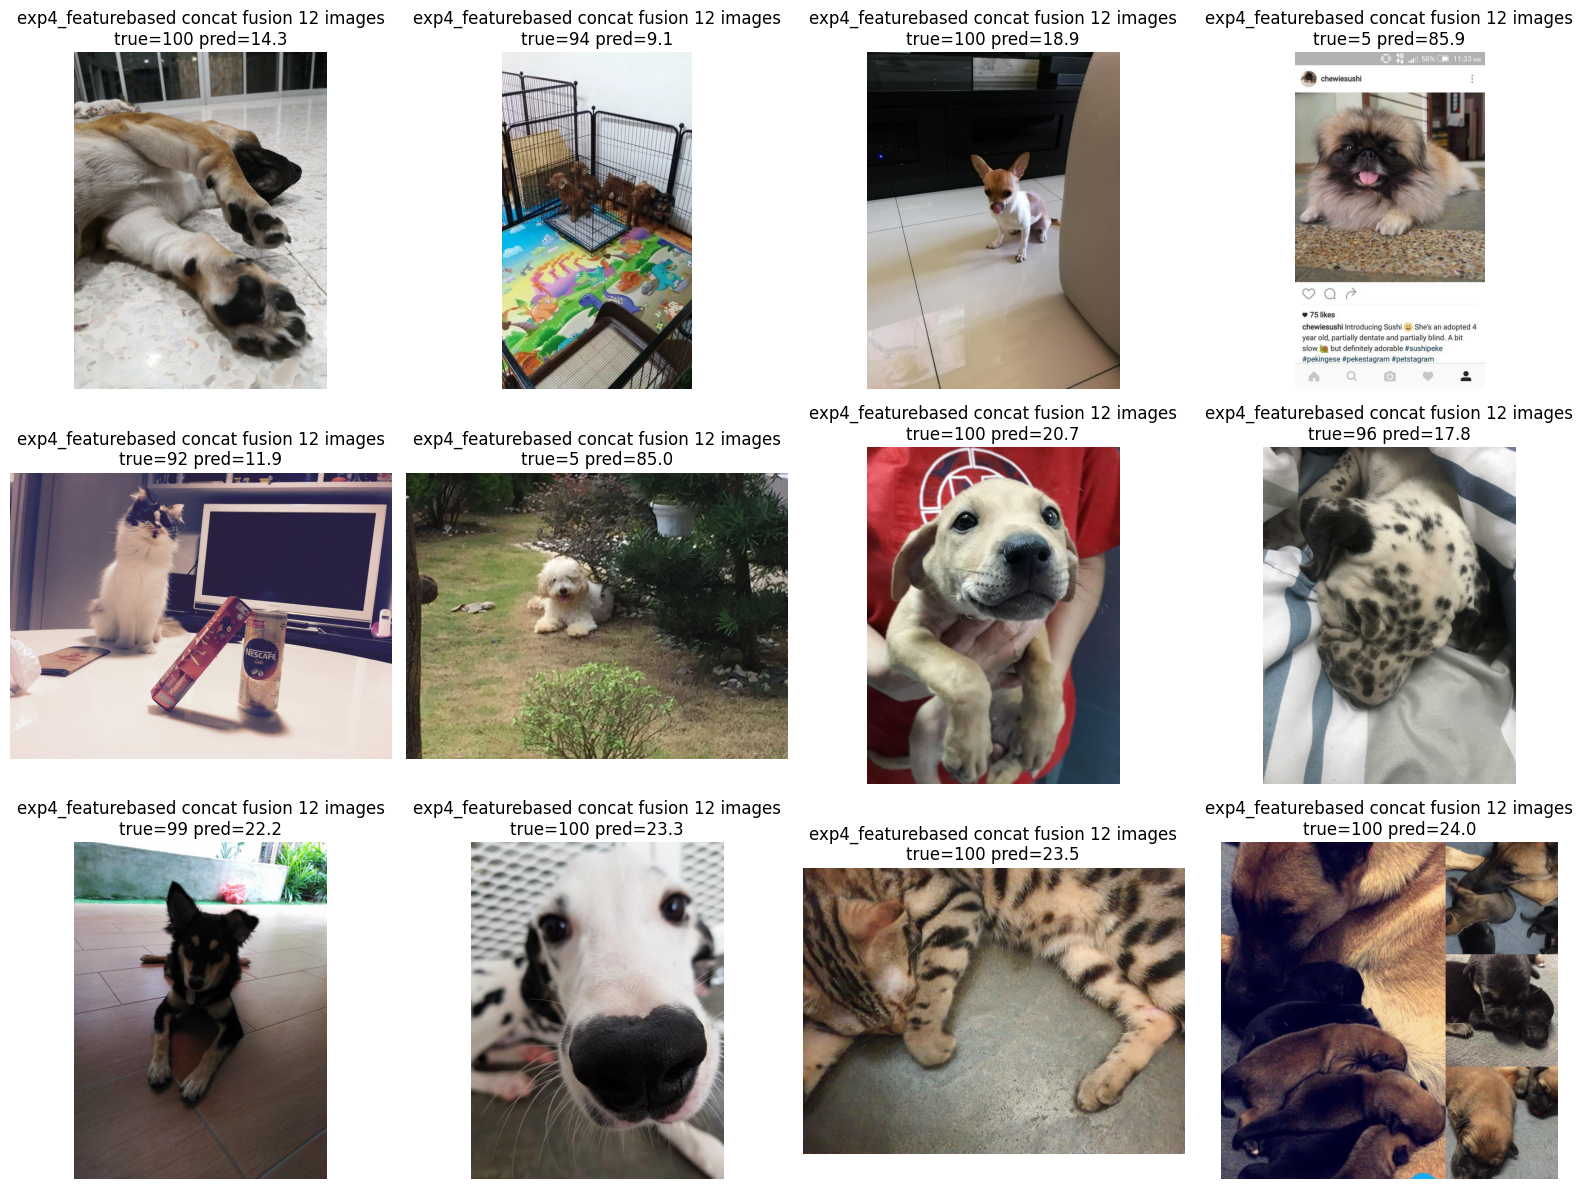

In [14]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")